# 11.1.1 从边表到结构统计

## 学习目标与先修知识

用明确的边语义构造邻接矩阵（adjacency matrix）、度、分量与路径。

先修：3.2 多变量状态（state）；5.4 随机过程（stochastic process）。只需会读列表、矩阵（matrix）并用 Python 循环。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

四个细胞之间有三条已确认的交换通道。哪些细胞能通过通道相互到达？把边画成线还不足以回答，因为节点位置只是绘图安排。先定义节点和边，再计算结构。

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

以四节点路径 0—1—2—3 为例，手数度与最短路径，再用小表核对。

In [2]:
edges = [[0, 1], [1, 2], [2, 3]]
print('节点数 4；边数', len(edges), '；手算度 [1,2,2,1]；最远两点相隔3条边。')

节点数 4；边数 3 ；手算度 [1,2,2,1]；最远两点相隔3条边。


## 模型假设

节点编号 0—n−1；本节边无向、无自环、无重复、无权。边只表示确有连接，不表示物理距离、交换强度或感染概率（probability）；这些机制以后单独定义。

## 数学解释与推导

邻接矩阵（adjacency matrix）$A$ 的 $A_{ij}=A_{ji}=1$ 表示有边，否则为零，且 $A_{ii}=0$。度（degree）$d_i=\sum_j A_{ij}$；每条边对两端各贡献一，故 $\sum_i d_i=2|E|$。连通分量（connected component）是路径可达的极大节点集。无权最短路径长度是最少边数；全图平均仅在所有节点对可达且 $n>1$ 时定义，本章在断连时返回 `None`。广度优先搜索（breadth-first search，BFS）从一个起点逐层发现距离。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def adjacency(n, edges):
    """Undirected simple graph; edges contain two distinct zero-based node indices."""
    a = [[0] * n for _ in range(n)]
    for i, j in edges:
        a[i][j] = a[j][i] = 1
    return a


def graph_summary(n, edges):
    """Degrees, sorted connected components and all-pairs path mean (or None)."""
    a = adjacency(n, edges)
    degree = [sum(row) for row in a]
    remaining = set(range(n))
    components = []
    while remaining:
        start = min(remaining)
        queue = [start]
        remaining.remove(start)
        part = []
        for v in queue:
            part.append(v)
            for w in range(n):
                if a[v][w] and w in remaining:
                    remaining.remove(w)
                    queue.append(w)
        components.append(sorted(part))
    lengths = []
    for start in range(n):
        distance = [-1] * n
        distance[start] = 0
        queue = [start]
        for v in queue:
            for w in range(n):
                if a[v][w] and distance[w] < 0:
                    distance[w] = distance[v] + 1
                    queue.append(w)
        lengths.extend(distance[w] for w in range(start + 1, n) if distance[w] >= 0)
    mean_path = sum(lengths) / len(lengths) if len(components) == 1 and lengths else None
    return degree, components, mean_path

## 对照实验

在同样四个节点上比较路径、环和断边。图中位置固定仅供阅读；右侧统计由边表算出。

结构、度、分量数、全图平均路径： [('路径', [1, 2, 2, 1], 1, 1.6666666666666667), ('闭环', [2, 2, 2, 2], 1, 1.3333333333333333), ('断边', [1, 1, 1, 1], 2, None)]


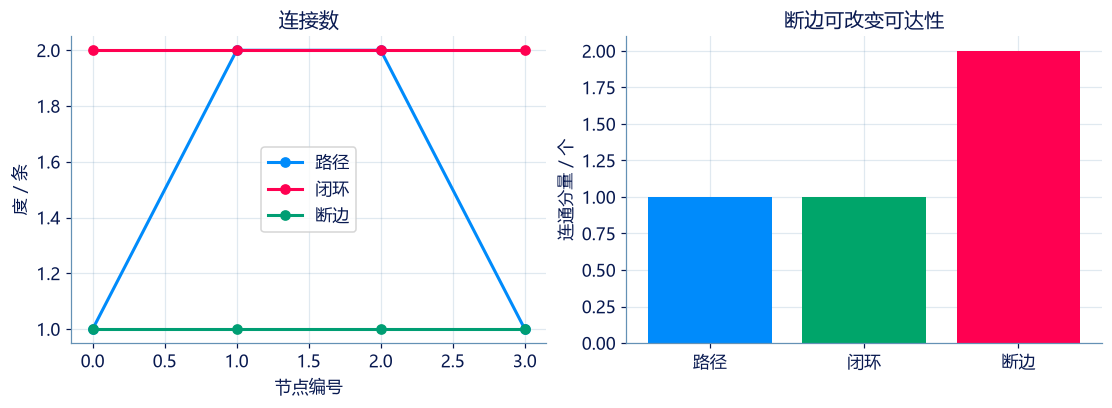

In [4]:
cases = {'路径': [[0,1],[1,2],[2,3]], '闭环': [[0,1],[1,2],[2,3],[3,0]], '断边': [[0,1],[2,3]]}
rows = []
for name, e in cases.items():
    degree, parts, mean_path = graph_summary(4, e)
    rows.append((name, degree, len(parts), mean_path))
print('结构、度、分量数、全图平均路径：', rows)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for i, (name, degree, parts, distance) in enumerate(rows):
    axes[0].plot(range(4), degree, marker='o', label=name)
axes[0].set(xlabel='节点编号', ylabel='度 / 条', title='连接数'); axes[0].legend()
axes[1].bar([r[0] for r in rows], [r[2] for r in rows], color=[BLUE, GREEN, PINK])
axes[1].set(ylabel='连通分量 / 个', title='断边可改变可达性'); plt.show()

## 结果解释

闭环让两个端点各增加一条边、路径平均缩短；断边让全图平均路径不再定义。度、路径和分量是不同问题，不能从布局线段长度推断。

### 独立核对

独立使用度和与边数关系，并手数四节点路径六对距离之和。

In [5]:
degree, parts, mean = graph_summary(4, edges)
assert sum(degree) == 2*len(edges)
assert parts == [[0,1,2,3]]
np.testing.assert_allclose(mean, 10/6)
assert graph_summary(4, cases['断边'])[2] is None
print('度和、手算距离与断连边界一致。')

度和、手算距离与断连边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算小图的结构统计

节点编号从0到n−1，edges 的每项 [i,j] 表示一条无向、无权、无自环的边且不重复。返回度、按最小节点排序的连通分量（connected component）和全图不同节点对的平均最短路径长度；若图不连通或 n=1，路径平均值返回 None。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
) -> tuple[list[int], list[list[int]], float | None]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 节点总数。 | 个 |
| `edges` | `list[list[int]]` | 无向简单边，每条只列一次。 | 条 |

**返回值**

按以下顺序返回元组：(degrees, components, mean_path)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `degrees` | `list[int]` | 按节点编号排列的度。 | 条 |
| `components` | `list[list[int]]` | 每个分量及分量顺序均升序。 | 节点编号 |
| `mean_path` | <code>float &#124; None</code> | 全图平均最短边数；未定义时为 None。 | 边 |

**计算规则**

先构造对称邻接矩阵（adjacency matrix）；用 BFS 找分量及从每个起点的距离。只对 i<j 计一次；有不可达对则 mean_path=None。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 节点总数。 | 4 | 个 |
| edges | 无向简单边，每条只列一次。 | [[0, 1], [1, 2], [2, 3]] | 条 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 4
edges = [[0, 1], [1, 2], [2, 3]]

result = solve(n, edges)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| degrees | 按节点编号排列的度。 | [1, 2, 2, 1] | 条 |
| components | 每个分量及分量顺序均升序。 | [[0, 1, 2, 3]] | 节点编号 |
| mean_path | 全图平均最短边数；未定义时为 None。 | ≈ 1.666667 | 边 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([1, 2, 2, 1],
                   [[0, 1, 2, 3]],
                   1.6666666666666667)
```

**样例解释**

四节点路径的度为[1,2,2,1]；6 对距离之和为10，故平均为10/6。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算小图的结构统计](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-small-graph-statistics)

### 第 2 题 · 多项选择题：边的含义先于矩阵

把同一份边表用于物质交换与人与人接触。哪些信息必须先说明？

- **A.** 节点和边分别代表什么。
- **B.** 边有无方向、权重表示交换率还是接触次数。
- **C.** 绘图软件给出的坐标一定是实际空间位置。
- **D.** 图中边的颜色由物理定律唯一决定。

[作答：边的含义先于矩阵](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-edge-semantics)

### 第 3 题 · 单项选择题：闭合四节点路径后

四节点路径0—1—2—3再增加边3—0，新的度序列与分量数是什么？

- **A.** [2,2,2,2]，1个分量。
- **B.** [1,2,2,1]，2个分量。
- **C.** [2,2,2,2]，4个分量。
- **D.** [3,3,3,3]，1个分量。

[作答：闭合四节点路径后](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-hand-drawn-path)

### 第 4 题 · 多项选择题：度数总和检查

无向简单图共有 m 条边。哪些陈述正确？

- **A.** 所有节点的度之和为2m。
- **B.** 每条边在两个端点各贡献1度。
- **C.** 度之和必等于m。
- **D.** 用布局距离可以直接替代最短边数。

[作答：度数总和检查](http://127.0.0.1:8000/chapters/11-01-%E4%BB%8E%E8%BF%9E%E6%8E%A5%E7%BB%93%E6%9E%84%E8%BF%9B%E5%85%A5%E7%BD%91%E7%BB%9C%E7%A7%91%E5%AD%A6/practice/?question=p11-degree-sum)

**进一步阅读**

[NetworkX 官方最短路径文档](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html)列出加权/无权路径的区别；本节代码显式实现小图 BFS。